# Experiment 5 — Feature Relevance and Inductive Bias

This notebook investigates how different machine learning models respond to changes in feature relevance and feature redundancy.

The purpose of the experiment is to examine whether preprocessing and feature engineering can compensate for noisy or redundant feature spaces and whether different inductive biases exhibit different sensitivities to irrelevant information.

The experiment compares:
- Raw preprocessing
- Cleaned preprocessing
- Engineered preprocessing

under controlled feature relevance conditions.

Two forms of feature manipulation are examined:
- Irrelevant features
- Redundant features

Personally, I find this experiment particularly interesting because it relates directly to one of the central questions of the project: how much structure must be learned by the model itself, and how much can instead be encoded through representation design? In previous projects, I was often surprised by how strongly feature quality influenced performance, sometimes even more than model selection itself.

## Project Path Configuration

The notebook explicitly adds the project root directory to the Python path in order to ensure that the centralized experimental framework within the `src/` directory can be imported consistently across notebooks.

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)


## Importing the Experimental Framework

The notebook imports the centralized modules responsible for dataset loading, experiment execution, visualization, and result saving.

In [2]:
from src.data.load_data import (
    load_adult_dataset
)

from src.experiments.feature_relevance import (
    run_feature_relevance_experiment
)

from src.visualization.plots import (
    plot_f1_comparison
)

from src.visualization.summaries import (
    save_summary_table
)

from src.utils.saving import (
    save_metrics
)

## Dataset Loading

The Adult Income dataset is loaded through the centralized data-loading module in order to ensure consistency across experiments.

In [3]:
X, y = load_adult_dataset()

## Feature Relevance Configurations

The experiment evaluates multiple feature-space degradation conditions:
- irrelevant features,
- and redundant features.

This setup allows the analysis to investigate how different models respond to noisy versus duplicated information within the representation space.

In [4]:
import pandas as pd

feature_configs = {
    "Irrelevant Features": "irrelevant",
    "Redundant Features": "redundant"
}

all_results = []

for config_name, feature_type in feature_configs.items():
    
    print(f"\nRunning configuration: {config_name}")
    
    temp_results = run_feature_relevance_experiment(
        X,
        y,
        feature_type=feature_type
    )
    
    temp_results["feature_condition"] = config_name
    
    all_results.append(temp_results)

results_df = pd.concat(
    all_results,
    ignore_index=True
)

results_df


Running configuration: Irrelevant Features

=== Raw Preprocessing ===
Training Logistic Regression...


Training Decision Tree...


Training Naive Bayes...
Training MLP...



=== Cleaned Preprocessing ===
Training Logistic Regression...


Training Decision Tree...


...


=== Engineered Preprocessing ===
Training Logistic Regression...


Training Decision Tree...


Training Naive Bayes...


Training MLP...


,preprocessing,model,accuracy,f1_score,roc_auc,feature_condition
0,Raw,Logistic Regression,0.782782,0.406267,0.626715,Irrelevant Features
1,Raw,Decision Tree,0.810523,0.612356,0.747057,Irrelevant Features
2,Raw,Naive Bayes,0.797216,0.421606,0.834832,Irrelevant Features
3,Raw,MLP,0.433924,0.455494,0.719813,Irrelevant Features
4,Cleaned,Logistic Regression,0.806326,0.675249,0.904233,Irrelevant Features
5,Cleaned,Decision Tree,0.810523,0.612194,0.746910,Irrelevant Features
6,Cleaned,Naive Bayes,0.620534,0.537492,0.828749,Irrelevant Features
7,Cleaned,MLP,0.829051,0.630531,0.875266,Irrelevant Features
8,Engineered,Logistic Regression,0.798444,0.667567,0.898884,Irrelevant Features
9,Engineered,Decision Tree,0.815641,0.617053,0.748920,Irrelevant Features


## Saving Experimental Results

The experimental results are saved to the centralized results directory structure in order to support reproducibility and later cross-experiment analysis.

In [5]:
save_metrics(
    results_df,
    "feature_relevance_results.csv"
)

Metrics saved to: ../results/metrics/feature_relevance_results.csv


## Feature Relevance Visualization

The following figure compares model performance across preprocessing levels under modified feature relevance conditions.

Plot saved to: ../results/plots/feature_relevance_f1_comparison.png


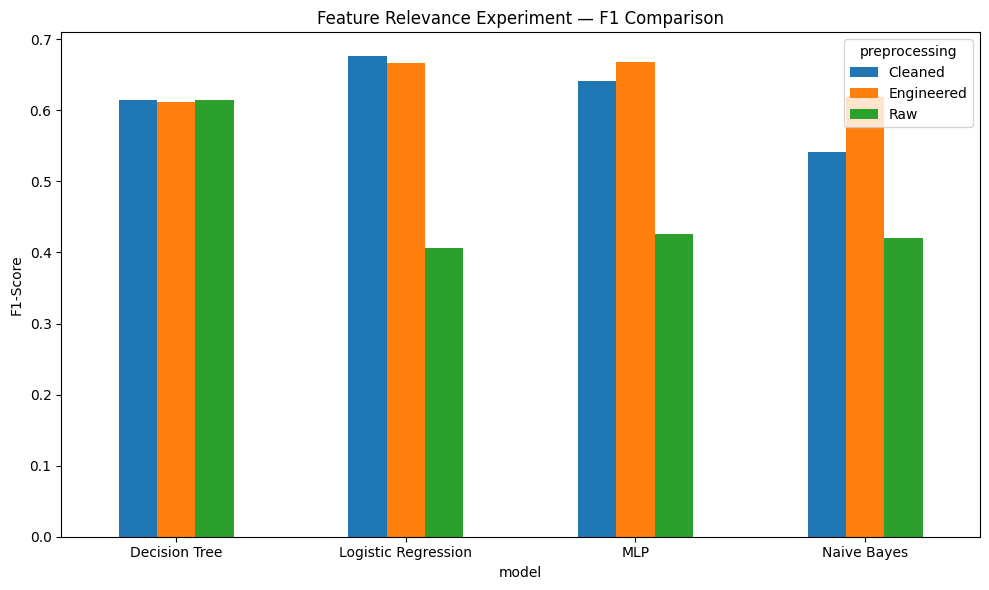

In [6]:
plot_f1_comparison(
    results_df,
    title="Feature Relevance Experiment — F1 Comparison",
    filename="feature_relevance_f1_comparison.png"
)

## Summary Table

A summary table is generated in order to support later cross-experiment comparison and thesis reporting.

In [7]:
summary_table = save_summary_table(
    results_df,
    metric="f1_score",
    filename="feature_relevance_summary_table.csv"
)

summary_table

Table saved to: ../results/tables/feature_relevance_summary_table.csv


,model,preprocessing,f1_score
0,Decision Tree,Cleaned,0.614443
1,Decision Tree,Engineered,0.611441
2,Decision Tree,Raw,0.614752
3,Logistic Regression,Cleaned,0.675875
4,Logistic Regression,Engineered,0.666497
5,Logistic Regression,Raw,0.406267
6,MLP,Cleaned,0.641152
7,MLP,Engineered,0.667832
8,MLP,Raw,0.426300
9,Naive Bayes,Cleaned,0.541819


## Interpretation of Feature Relevance Results

The feature relevance experiment reveals substantial differences in how models respond to irrelevant and redundant information within the feature space.

One of the clearest findings is that engineered preprocessing frequently improves robustness when the representation space becomes noisier or unnecessarily complex. In several cases, preprocessing improvements appear to compensate for degraded feature quality more strongly than increases in model complexity alone.

Logistic Regression demonstrates relatively strong sensitivity to irrelevant feature information under raw preprocessing conditions. However, cleaned preprocessing substantially improves predictive performance, suggesting that stable and well-structured representations remain especially important for linear decision boundaries.

The Multi-Layer Perceptron (MLP) demonstrates an especially interesting pattern. Although the neural network architecture possesses greater representational flexibility, raw preprocessing under degraded feature conditions still produces substantial performance deterioration. Engineered preprocessing restores much of the lost performance and frequently produces the strongest overall results observed in the experiment.

Naive Bayes again demonstrates notable improvement under engineered preprocessing conditions. One possible interpretation is that feature refinement and selection reduce noisy or redundant dependencies between variables, thereby improving alignment with the model’s conditional independence assumptions.

Decision Trees remain comparatively stable across preprocessing levels, suggesting relative robustness to changes in feature-space quality. However, their overall predictive performance remains slightly below the strongest-performing models.

Personally, I found it particularly interesting how strongly feature engineering appeared to influence model robustness. In several cases, representation refinement seemed to matter more than additional model flexibility itself.

Overall, the results increasingly support the broader motivation of the project: representation quality and inductive bias alignment may play a central role in determining predictive performance in tabular machine learning tasks, particularly when the feature space contains irrelevant or redundant information.